# TF-IDF vs BM25: разбор отличий по компонентам формул

Оба метода решают одну и ту же задачу — оценить релевантность документа `d` на основе запроса `q`, используя информацию о том, какие термины запроса встречаются в документе и насколько они информативны. Базовая идея: term frequency (TF) × inverse document frequency (IDF).

**Гипотезы:**

1. TF-насыщение. Вклад термина в TF-IDF растёт с частотой без потолка, поэтому повтор слова неограниченно завышает скор; в BM25 вклад выходит на плато `k1 + 1`.
2. Нормализация длины. При увеличении документа нерелевантным текстом TF-IDF снижает вес термина косвенно — через рост L2-нормы всего вектора, тогда как BM25 штрафует длину напрямую и управляемо через `b` (от `b=0` без штрафа до `b=1` с максимальным).
3. IDF на крайних случаях. Для термина из всех документов базовый Okapi-IDF в BM25 уходит в отрицательную зону и спасается только epsilon-флором; для редкого термина (df=1) отключение сглаживания (`smooth_idf=False`) в TF-IDF заметно усиливает его вес.
4. Итог на реальных данных. На NFCorpus с сильно скошенным распределением длины эти отличия дают BM25 преимущество над TF-IDF по nDCG/Recall/MRR при дефолтных гиперпараметрах.

In [1]:
import re
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from rank_bm25 import BM25Okapi

sns.set_theme(style="whitegrid", palette="deep")

In [2]:
def tokenize(text: str) -> list[str]:
    """Простой токенизатор: нижний регистр + только слова."""
    return re.findall(r"[a-zA-Zа-яА-Я0-9]+", text.lower())

## 2. TF: насыщение частоты термина (TF-spamming)

Гипотеза 1 на одном документе: фиксированную основу повторяем термином `cat` с частотой от 1 до 1000 и смотрим, как растёт вклад термина в скор. Изучаем только TF-компонент.

Сравниваем:
- TF-IDF: сырой `tf` и сублинейный `1 + log(tf)`
- BM25: `k1=1.2` (быстрое насыщение) и `k1=10` (позднее насыщение)
- Предел насыщения BM25 `k1 + 1`

In [3]:
def repeat_term_doc(n_repeats: int, term: str = "cat", base: str = "sat on the mat") -> str:
    """
    Создает документ с неизменной основой + термин, который повторяется n_repeats раз.

    Args:
        n_repeats: Количество повторения термина.
        term: Повторяемый термин.
        base: Неизменная основа документа.

    Returns:
        Токены документа (list[str]).
    """
    return tokenize(f"{base} " + " ".join([term] * n_repeats))


def bm25_tf_saturation(tf: int, k1: float) -> float:
    """BM25-компонент насыщения TF (без нормализации длины).

    Args:
        tf: Частота термина в документе.
        k1: Параметр насыщения BM25.

    Returns:
        Насыщенный вклад термина; при росте tf стремится к пределу k1 + 1.
    """
    return tf * (k1 + 1) / (tf + k1)

In [4]:
term = "cat"
rows = []
for n in range(1, 1000):
    tf = Counter(repeat_term_doc(n, term=term))[term]
    rows.append({"tf": tf, "method": "TF-IDF (raw tf)", "score": tf})
    rows.append({"tf": tf, "method": "TF-IDF (1 + log tf)", "score": 1 + np.log(tf)})
    
    for k1 in (1.2, 10.0):
        rows.append({"tf": tf, "method": f"BM25 (k1={k1})", "score": bm25_tf_saturation(tf, k1)})

tf_df = pd.DataFrame(rows)
tf_df.head()

,tf,method,score
0,1,TF-IDF (raw tf),1.0
1,1,TF-IDF (1 + log tf),1.0
2,1,BM25 (k1=1.2),1.0
3,1,BM25 (k1=10.0),1.0
4,2,TF-IDF (raw tf),2.0


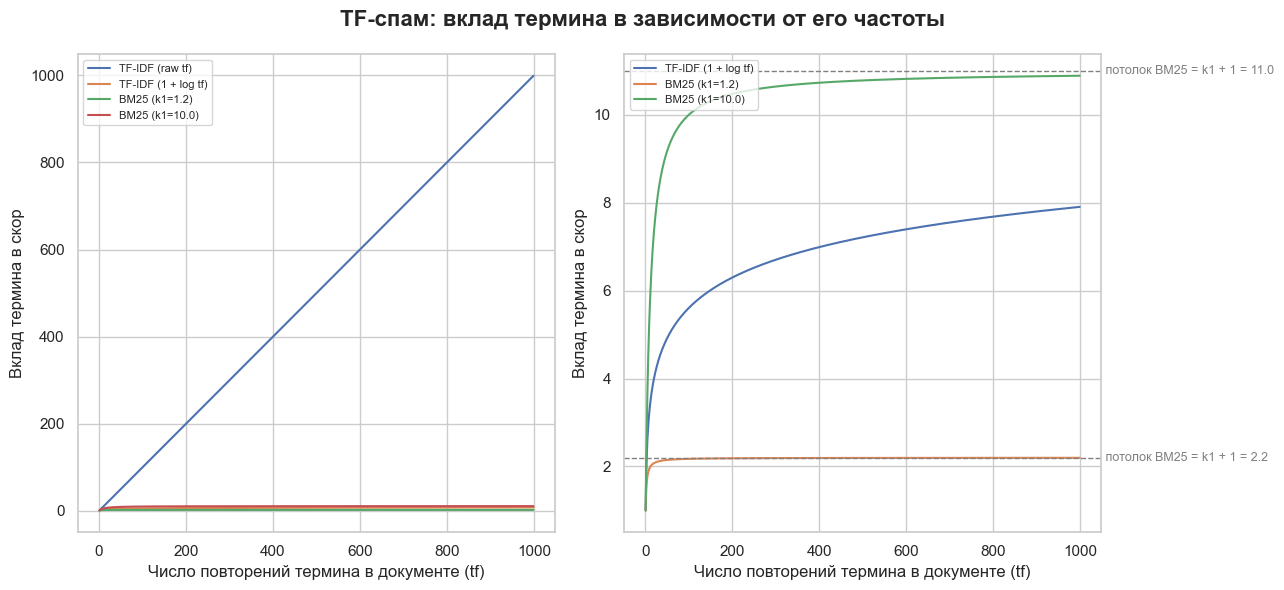

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(13, 6))

sns.lineplot(data=tf_df, x="tf", y="score", hue="method", ax=ax[0])
ax[0].set_xlabel("Число повторений термина в документе (tf)")
ax[0].set_ylabel("Вклад термина в скор")
ax[0].legend(loc="upper left", fontsize=8)

sns.lineplot(data=tf_df[tf_df["method"] != "TF-IDF (raw tf)"], x="tf", y="score", hue="method", ax=ax[1])
for k1 in (1.2, 10.0):
    ax[1].axhline(k1 + 1, color="gray", linestyle="--", linewidth=1)
    ax[1].text(1050, k1 + 1, f" потолок BM25 = k1 + 1 = {k1 + 1}", va="center", color="gray", fontsize=9)
ax[1].set_xlabel("Число повторений термина в документе (tf)")
ax[1].set_ylabel("Вклад термина в скор")
ax[1].legend(loc="upper left", fontsize=8)

fig.suptitle("TF-спам: вклад термина в зависимости от его частоты", fontweight="bold", fontsize=16)
plt.tight_layout()
plt.show()

**Вывод:** Гипотеза 1 подтверждена: сырой `tf` растёт линейно, `1 + log(tf)` — медленнее, но тоже без потолка; только BM25 насыщается на `k1 + 1`. На практике: TF-IDF на сыром `tf` уязвим к keyword-stuffing, BM25 — нет, а `k1` задаёт, как быстро повторы перестают добавлять скор (меньше `k1` → раньше плато).

## 3. Нормализация длины документа

Гипотеза 2 на одном документе: неизменная основа `the cat sat on the mat` (`tf(cat)=1`), к которой добавляем нерелевантный filler, меняя только длину. Средняя длина `avgdl` == длине основы.

Сравниваем:
- TF-IDF: `norm='l2'` (по умолчанию) и `norm=None` (без нормализации)
- BM25: `b ∈ {0, 0.5, 0.75, 1.0}` при фиксированном `k1=1.5`

In [6]:
def padded_doc(n_filler: int, base: str = "the cat sat on the mat", filler: str = "filler") -> str:
    """
    Создает документ с неизменной основой + n_filler слов-наполнителей.

    Args:
        n_filler: Количество filler-слов.
        base: Неизменная основа документа.
        filler: Слово-наполнитель.

    Returns:
        Токены документа (list[str]).
    """
    return tokenize(f"{base} " + " ".join([filler] * n_filler))


def bm25_length_norm(tf: int, dl: int, avgdl: int, k1: int = 1.5, b: int = 0.75) -> float:
    """
    BM25-компонент TF с нормализацией длины документа.

    Args:
        tf: Частота термина в документе.
        dl: Длина документа в токенах.
        avgdl: Средняя длина документа.
        k1: Параметр насыщения.
        b: Сила нормализации.

    Returns:
        Вклад термина с поправкой на длину документа.
    """
    norm = 1 - b + b * dl / avgdl
    return tf * (k1 + 1) / (tf + k1 * norm)


def tfidf_l2_weight(doc: str, term: str) -> float:
    """
    Вес термина при L2-нормализации вектора документа.

    Args:
        doc: Токены документа.
        term: Термин.

    Returns:
        tf термина, делённый на L2-норму вектора частот документа.
    """
    counts = Counter(doc)
    return counts[term] / np.linalg.norm(list(counts.values()))

In [7]:
term = "cat"
avgdl = len(tokenize("the cat sat on the mat"))
rows = []
for n_filler in range(0, 51, 5):
    doc = padded_doc(n_filler)
    dl, tf = len(doc), Counter(doc)[term]
    
    rows.append({"doc_length": dl, "method": "TF-IDF (norm=l2)", "score": tfidf_l2_weight(doc, term)})
    rows.append({"doc_length": dl, "method": "TF-IDF (norm=None)", "score": float(tf)})
    for b in (0.0, 0.5, 0.75, 1.0):
        rows.append({"doc_length": dl, "method": f"BM25 (b={b})", "score": bm25_length_norm(tf, dl, avgdl, b=b)})

length_df = pd.DataFrame(rows)
length_df.head()

,doc_length,method,score
0,6,TF-IDF (norm=l2),0.353553
1,6,TF-IDF (norm=None),1.000000
2,6,BM25 (b=0.0),1.000000
3,6,BM25 (b=0.5),1.000000
4,6,BM25 (b=0.75),1.000000


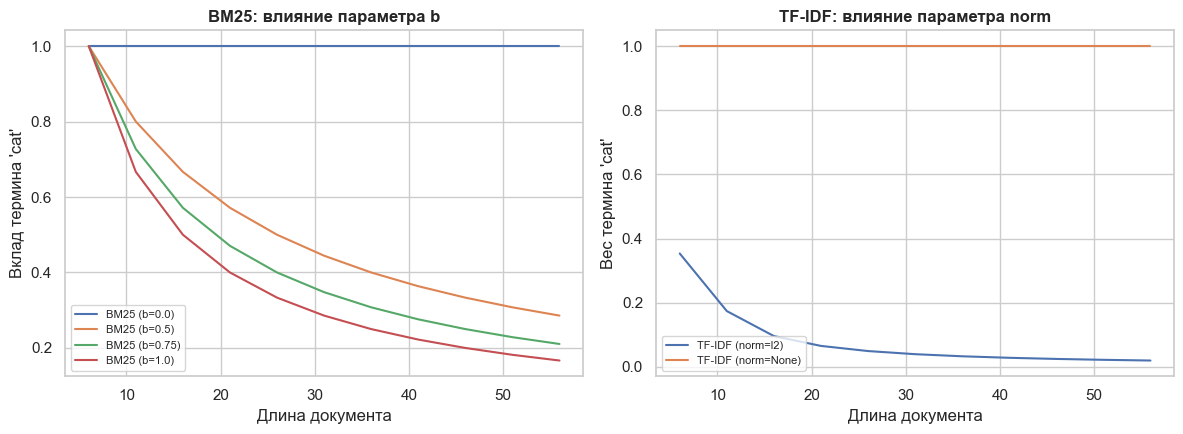

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

bm25_part = length_df[length_df["method"].str.startswith("BM25")]
tfidf_part = length_df[length_df["method"].str.startswith("TF-IDF")]

sns.lineplot(data=bm25_part, x="doc_length", y="score", hue="method", ax=axes[0])
axes[0].set_title("BM25: влияние параметра b", fontweight="bold")
axes[0].set_xlabel("Длина документа")
axes[0].set_ylabel("Вклад термина 'cat'")
axes[0].legend(loc="lower left", fontsize=8)

sns.lineplot(data=tfidf_part, x="doc_length", y="score", hue="method", ax=axes[1])
axes[1].set_title("TF-IDF: влияние параметра norm", fontweight="bold")
axes[1].set_xlabel("Длина документа")
axes[1].set_ylabel("Вес термина 'cat'")
axes[1].legend(loc="lower left", fontsize=8)

plt.tight_layout()
plt.show()

**Вывод:** Гипотеза 2 подтверждена: BM25 штрафует длину явно и управляемо через `b` (0 — игнор, 1 — максимум), а TF-IDF снижает вес лишь косвенно — через L2-норму вектора, и при `norm=None` защита от «разбавления» документа пропадает совсем. На практике: на корпусах с разбросом длин держите `b≈0.75` в BM25 и не отключайте нормализацию в TF-IDF.

## 4. IDF: сглаживание и редкие/частые термины

Гипотеза 3 на маленьком 5-документном корпусе, где термины встречаются с разной частотой:
- `health` — встречается во **всех 5** документах (`df=N`, крайний случай "частого" термина)
- `protein` — встречается в **2 из 5** документов
- `quinoa` — встречается в **1 из 5** документов (крайний случай "редкого" термина)

In [9]:
idf_docs = [
    "health diet quinoa protein",
    "health exercise protein",
    "health sleep",
    "health nutrition",
    "health vitamins",
]
terms_of_interest = ["health", "protein", "quinoa"]

tfidf_smooth = TfidfVectorizer(smooth_idf=True)
tfidf_smooth.fit(idf_docs)
tfidf_raw = TfidfVectorizer(smooth_idf=False)
tfidf_raw.fit(idf_docs)

tokenized_idf_docs = [tokenize(d) for d in idf_docs]
bm25_idf = BM25Okapi(tokenized_idf_docs)

N_docs = len(idf_docs)
N_docs

5

In [10]:
def df_of(term: str) -> float:
    """
    Document frequency термина в корпусе idf_docs.

    Args:
        term: Искомый термин.

    Returns:
        Число документов, содержащих термин.
    """
    return sum(1 for d in tokenized_idf_docs if term in d)


def raw_bm25_idf(term: str) -> float:
    """Базовая формула Okapi IDF без epsilon-флора.

    Args:
        term: Искомый термин.

    Returns:
        Значение IDF по формуле log((N - df + 0.5) / (df + 0.5)).
    """
    df = df_of(term)
    return np.log((N_docs - df + 0.5) / (df + 0.5))

In [11]:
idf_rows = []
for term in terms_of_interest:
    feat_smooth = list(tfidf_smooth.get_feature_names_out())
    feat_raw = list(tfidf_raw.get_feature_names_out())
    smooth_val = tfidf_smooth.idf_[feat_smooth.index(term)]
    raw_val = tfidf_raw.idf_[feat_raw.index(term)]
    bm25_floored = bm25_idf.idf.get(term, 0.0)
    bm25_raw = raw_bm25_idf(term)
    idf_rows.append({"term": term, "method": "TF-IDF smooth_idf=True", "idf": smooth_val})
    idf_rows.append({"term": term, "method": "TF-IDF smooth_idf=False", "idf": raw_val})
    idf_rows.append({"term": term, "method": "BM25 idf (raw, без epsilon)", "idf": bm25_raw})
    idf_rows.append({"term": term, "method": "BM25 idf (с epsilon-флором)", "idf": bm25_floored})

idf_df = pd.DataFrame(idf_rows)
idf_df

,term,method,idf
0,health,TF-IDF smooth_idf=True,1.000000
1,health,TF-IDF smooth_idf=False,1.000000
2,health,"BM25 idf (raw, без epsilon)",-2.397895
3,health,BM25 idf (с epsilon-флором),0.141570
4,protein,TF-IDF smooth_idf=True,1.693147
5,protein,TF-IDF smooth_idf=False,1.916291
6,protein,"BM25 idf (raw, без epsilon)",0.336472
7,protein,BM25 idf (с epsilon-флором),0.336472
8,quinoa,TF-IDF smooth_idf=True,2.098612
9,quinoa,TF-IDF smooth_idf=False,2.609438


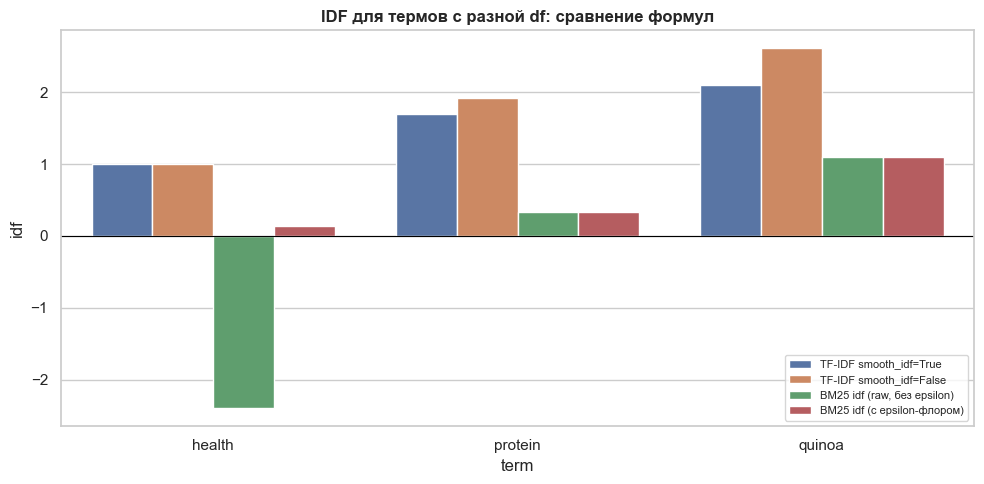

In [12]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=idf_df, x="term", y="idf", hue="method", ax=ax)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("IDF для термов с разной df: сравнение формул", fontweight="bold")
ax.legend(loc="lower right", fontsize=8)

plt.tight_layout()
plt.show()

**Вывод:** Гипотеза 3 подтверждена: `smooth_idf=False` сильнее поднимает вес редких термов (`quinoa`, df=1), а базовый Okapi-IDF для слова из всех документов (`health`) отрицателен, и epsilon-флор поднимает его до малого положительного порога. На практике: epsilon-флор в BM25 обязателен (иначе частые слова штрафуют релевантные документы), а `smooth_idf` регулирует, насколько агрессивно поощряются редкие термины.

## 5. Загрузка NFCorpus (BEIR)

In [13]:
from beir import util
from beir.datasets.data_loader import GenericDataLoader
from tqdm.autonotebook import tqdm

url = "https://public.ukp.informatik.tu-darmstadt.de/thakur/BEIR/datasets/nfcorpus.zip"
data_path = util.download_and_unzip(url, "datasets")
corpus, queries, qrels = GenericDataLoader(data_path).load(split="test")

print(f"Документов в корпусе: {len(corpus)}")
print(f"Запросов: {len(queries)}")
print(f"Запросов с qrels: {len(qrels)}")
print(f"Среднее число релевантных документов на запрос: {np.mean([len(v) for v in qrels.values()]):.1f}")

/Users/egorkainov/Desktop/tfidf_bm25_compare/.venv/lib/python3.10/site-packages/beir/util.py:11: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


datasets/nfcorpus.zip:   0%|          | 0.00/2.34M [00:00<?, ?iB/s]

  0%|          | 0/3633 [00:00<?, ?it/s]

Документов в корпусе: 3633
Запросов: 323
Запросов с qrels: 323
Среднее число релевантных документов на запрос: 38.2


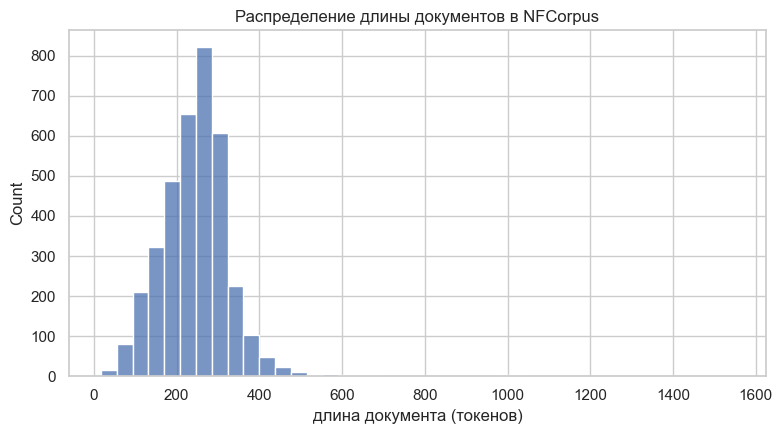

In [14]:
doc_ids = list(corpus.keys())
doc_texts = [
    (corpus[did].get("title", "") + " " + corpus[did].get("text", "")).strip()
    for did in doc_ids
]
doc_lengths = np.array([len(tokenize(t)) for t in doc_texts])

fig, ax = plt.subplots(figsize=(8, 4.5))
sns.histplot(doc_lengths, bins=40, ax=ax)
ax.set_xlabel("длина документа (токенов)")
ax.set_title("Распределение длины документов в NFCorpus")

plt.tight_layout()
plt.show()

In [15]:
print(f"Средняя длина документа: {doc_lengths.mean():.1f} токенов")
print(f"Медиана: {np.median(doc_lengths):.1f}, std: {doc_lengths.std():.1f}")
print(f"Мин/Макс: {doc_lengths.min()} / {doc_lengths.max()}")

Средняя длина документа: 245.8 токенов
Медиана: 249.0, std: 89.6
Мин/Макс: 17 / 1547


**Вывод:** Длина документов сильно скошена вправо (короткое тело + длинный хвост), поэтому разница в нормализации длины здесь не теоретическая. На практике: именно на длинном хвосте TF-IDF и BM25 разойдутся, и ждём измеримый разрыв в метриках в пользу BM25 (проверяем в Section 7).

## 6. Индексация и ранжирование на NFCorpus

In [16]:
TOP_K = 100

tokenized_corpus = [tokenize(t) for t in doc_texts]
bm25_default = BM25Okapi(tokenized_corpus, k1=1.5, b=0.75)
tfidf_vectorizer = TfidfVectorizer()
tfidf_matrix = tfidf_vectorizer.fit_transform(doc_texts)

In [17]:
def rank_bm25(bm25_model, query_text, top_k=TOP_K):
    """
    Top-k документов по BM25 для запроса.

    Args:
        bm25_model: Модель BM25Okapi.
        query_text: Текст запроса.
        top_k: Сколько документов вернуть.

    Returns:
        Словарь {doc_id: score} для top_k документов.
    """
    scores = bm25_model.get_scores(tokenize(query_text))
    top_idx = np.argsort(scores)[::-1][:top_k]
    
    return {doc_ids[i]: float(scores[i]) for i in top_idx}


def rank_tfidf(vectorizer, matrix, query_text, top_k=TOP_K):
    """
    Top-k документов по косинусной близости TF-IDF.

    Args:
        vectorizer: Обученный TfidfVectorizer.
        matrix: TF-IDF матрица корпуса.
        query_text: Текст запроса.
        top_k: Сколько документов вернуть.

    Returns:
        Словарь {doc_id: score} для top_k документов.
    """
    q_vec = vectorizer.transform([query_text])
    sims = cosine_similarity(q_vec, matrix).ravel()
    top_idx = np.argsort(sims)[::-1][:top_k]
    
    return {doc_ids[i]: float(sims[i]) for i in top_idx}

In [18]:
results_bm25 = {qid: rank_bm25(bm25_default, qtext) for qid, qtext in queries.items()}
results_tfidf = {qid: rank_tfidf(tfidf_vectorizer, tfidf_matrix, qtext) for qid, qtext in queries.items()}

In [19]:
sample_qid = next(iter(queries))
print("Запрос:", queries[sample_qid])
print()
for label, results in [("BM25", results_bm25), ("TF-IDF", results_tfidf)]:
    print(f"--- {label} top-5 ---")
    top5 = sorted(results[sample_qid].items(), key=lambda kv: kv[1], reverse=True)[:5]
    for doc_id, score in top5:
        title = corpus[doc_id].get("title", "")[:90]
        print(f"  {score:.3f}  {title}")
    print()

Запрос: Do Cholesterol Statin Drugs Cause Breast Cancer?

--- BM25 top-5 ---
  21.321  Statin use after diagnosis of breast cancer and survival: a population-based cohort study.
  21.253  Statin use and risk of breast cancer: a meta-analysis of observational studies.
  19.329  Statin Use and Breast Cancer Survival: A Nationwide Cohort Study from Finland
  19.121  Women and statin use: a women's health advocacy perspective.
  18.446  The effects of lowering LDL cholesterol with statin therapy in people at low risk of vascu

--- TF-IDF top-5 ---
  0.475  Statin Use and Breast Cancer Survival: A Nationwide Cohort Study from Finland
  0.421  Statin use after diagnosis of breast cancer and survival: a population-based cohort study.
  0.403  Statin use and risk of breast cancer: a meta-analysis of observational studies.
  0.294  Statin therapy, muscle function and falls risk in community-dwelling older adults.
  0.292  Statin therapy induces ultrastructural damage in skeletal muscle in patie

## 7. Оценка качества: Recall@k, MRR, nDCG@k

In [20]:
from beir.retrieval.evaluation import EvaluateRetrieval

k_values = [5, 10, 20]


def evaluate_results(results, qrels, k_values=k_values):
    """
    Метрики качества ранжирования (nDCG, Recall, MRR) на k_values.

    Args:
        results: Результаты ранжирования {qid: {doc_id: score}}.
        qrels: Разметка релевантности.
        k_values: Уровни отсечения для метрик.

    Returns:
        Объединённый словарь метрик nDCG@k, Recall@k, MRR@k.
    """
    ndcg, _map, recall, precision = EvaluateRetrieval.evaluate(qrels, results, k_values)
    mrr = EvaluateRetrieval.evaluate_custom(qrels, results, k_values, metric="mrr")
    
    return {**ndcg, **recall, **mrr}

In [21]:
metrics_bm25 = evaluate_results(results_bm25, qrels)
metrics_tfidf = evaluate_results(results_tfidf, qrels)

summary_df = pd.DataFrame({"BM25": metrics_bm25, "TF-IDF": metrics_tfidf})
summary_df

,BM25,TF-IDF
NDCG@5,0.33389,0.31498
NDCG@10,0.30616,0.29009
NDCG@20,0.27815,0.26713
Recall@5,0.11505,0.11074
Recall@10,0.15222,0.14136
Recall@20,0.17212,0.16928
MRR@5,0.49923,0.47503
MRR@10,0.50845,0.48135
MRR@20,0.50977,0.48469


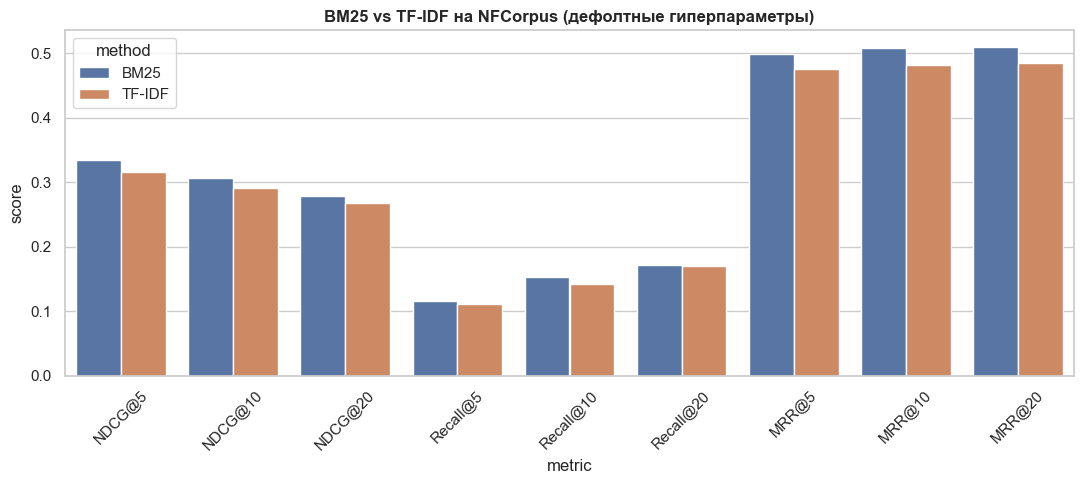

In [22]:
plot_df = summary_df.reset_index().melt(id_vars="index", var_name="method", value_name="score")
plot_df = plot_df.rename(columns={"index": "metric"})

fig, ax = plt.subplots(figsize=(11, 5))
sns.barplot(data=plot_df, x="metric", y="score", hue="method", ax=ax)
ax.set_title("BM25 vs TF-IDF на NFCorpus (дефолтные гиперпараметры)", fontweight="bold")
ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()